In [59]:
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [60]:
AUC_DIR = "/home/users/mendrika/NCAST/Output/evaluation/ncast/auc"

MODELS = [
    "base",
    "noattention",
    "notimefeat",
    "t0",
    "t0_tminus1h",
    "t0_tminus1h_tminus2h",
]

MODEL_LABELS = {
    "base": "NCAST",
    "noattention": "No self-attention",
    "notimefeat": "No temporal features",
    "t0": r"$t_0$ only",
    "t0_tminus1h": r"$t_0,\ t_{-1}$",
    "t0_tminus1h_tminus2h": r"$t_0,\ t_{-1},\ t_{-2}$",
}

LEAD_TIMES = ["1", "3", "6"]

def load_auc_results():
    rows = []

    for model_name in MODELS:
        for lead_time in LEAD_TIMES:

            auc_model_path = os.path.join(
                AUC_DIR,
                model_name,
                f"auc_model_t{lead_time}.npy"
            )

            if not os.path.exists(auc_model_path):
                print(f"Missing: {auc_model_path}")
                continue

            auc_model = float(np.load(auc_model_path))

            rows.append({
                "model_name": model_name,
                "model_label": MODEL_LABELS[model_name],
                "lead_time": int(lead_time),
                "auc_model": auc_model,
            })

    return pd.DataFrame(rows)

auc_df = load_auc_results()

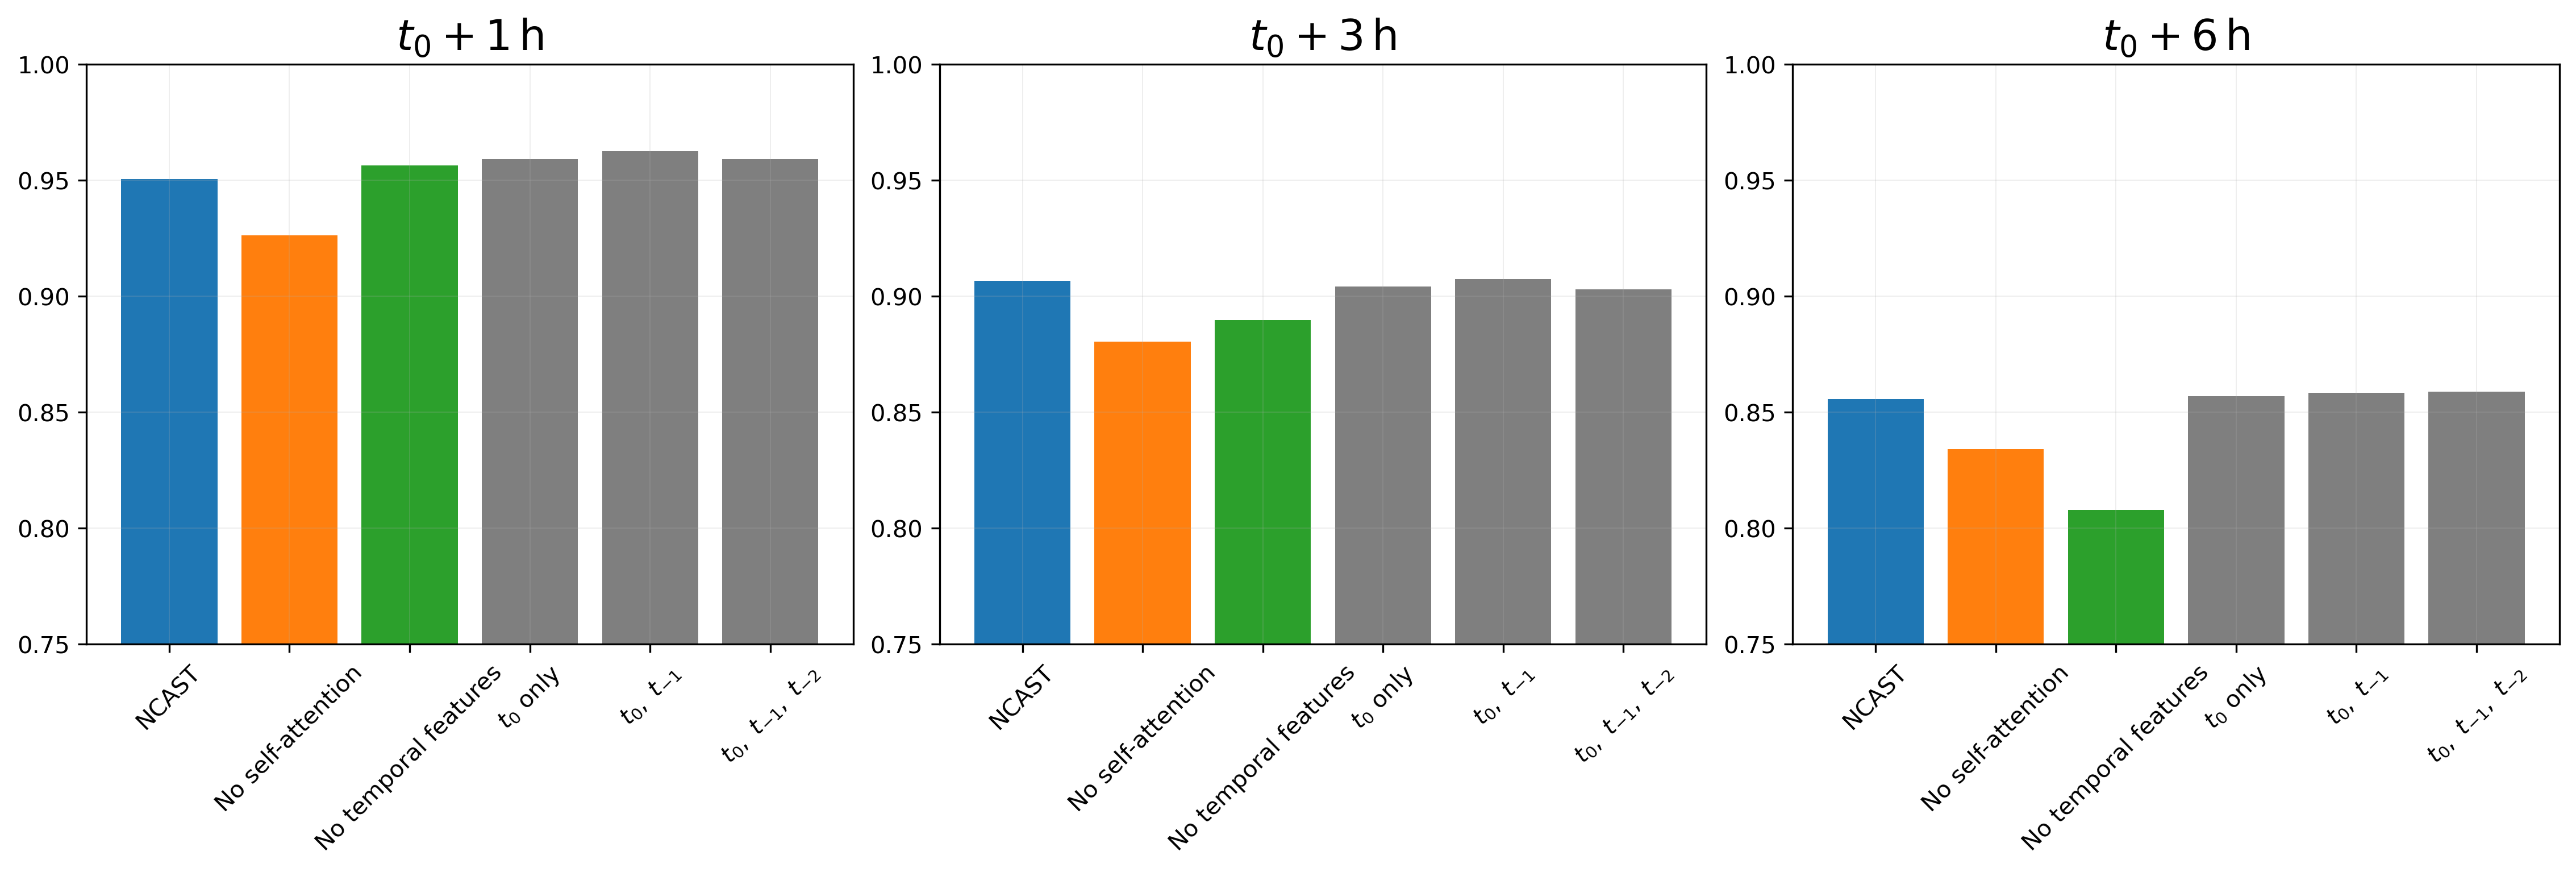

In [ ]:
colors = [
    "#1f77b4",  # NCAST
    "#ff7f0e",  # No self-attention
    "#2ca02c",  # No temporal features
    "#7f7f7f",  # t0 only
    "#7f7f7f",  # t0, t-1
    "#7f7f7f",  # t0, t-1, t-2
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    dpi=300,
    constrained_layout=True
)

for ax, lead_time in zip(axes, [1, 3, 6]):

    subset = auc_df[auc_df["lead_time"] == lead_time]

    bars = ax.bar(
        subset["model_label"],
        subset["auc_model"],
        color=colors
    )

    ax.set_ylim(0.75, 1)

    ax.set_title(
        rf"$t_0 + {lead_time}\,\mathrm{{h}}$",
        fontsize=18
    )
    
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, linewidth=0.1)

plt.show()